In [1]:
!pip install --upgrade landscape_tools

# Imports

In [2]:
from landscape_tools import exploratory_landscape_analysis as ela
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import Pauli

/home/gabriel/Desktop/public/landscape_visualisation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/gabriel/Desktop/public/landscape_visualisation/.venv/lib/python3.12/site-packages/vcs_versioning/_config.py:261: UserWarning: relative_to is expected to be a file, it's the directory /home/gabriel/Desktop/public/landscape_visualisation/.venv/lib/python3.12/site-packages
assuming the parent directory was passed
  return _check_absolute_root(self.root, self.relative_to)


# Example of a problem

## Probability distribution

In [3]:
def get_prob_distribution(params, ansatz, theta_params):

    param_dict = dict(zip(theta_params, params))                                
    # param_dict = {
    #     θ0: 0.5,
    #     θ1: 1.2
    # }

    bound_circuit = ansatz.assign_parameters(param_dict, inplace=False)

    state = Statevector.from_instruction(bound_circuit)
    probs = state.probabilities()

    return np.asarray(probs, dtype=float)

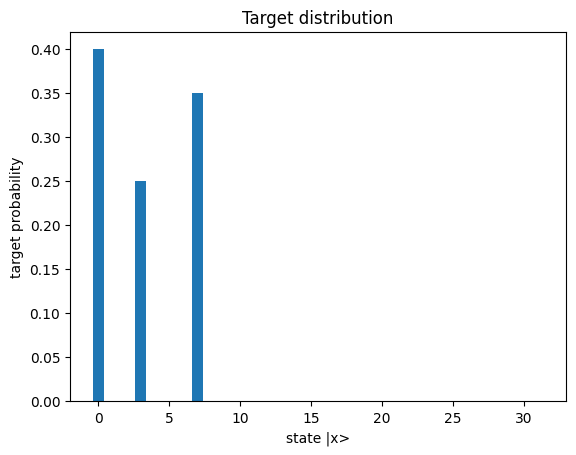

In [4]:
n_qubits = 5
dim = 2 ** n_qubits

p_target = np.zeros(dim)

# index 0 -> |000>, index 1 -> |001>, ..., index 7 -> |111>
p_target[0] = 0.40  # |000>
p_target[3] = 0.25  # |011>
p_target[7] = 0.35  # |111>

p_target = p_target / p_target.sum()    # normalize to ensure probabilities sum to 1

plt.bar(range(dim), p_target)
plt.xlabel("state |x>")
plt.ylabel("target probability")
plt.title("Target distribution")
plt.show()

## Quantum circuit

In [5]:
def build_hea_ansatz(n_qubits, n_layers, Ansatz):
    """
    Hardware Efficient Ansatz :
    - RY + RZ on each qubit
    - CNOT chain
    """
    qc = QuantumCircuit(n_qubits)

    n_params = 2 * n_qubits * n_layers
    theta = ParameterVector("θ", n_params)

    k = 0
    for _ in range(n_layers):
        for q in range(n_qubits):
            qc.ry(theta[k], q)
            k += 1
            qc.rz(theta[k], q)
            k += 1

        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)

    qc.metadata = {"parameters": theta, "ansatz_name": Ansatz,}

    return qc

In [6]:
def generate_params_hea(n_qubits, n_layers):
    """
    Generate random parameters for HEA ansatz (uniform distribution).
    """

    n_params = 2 * n_qubits * n_layers
    params = np.random.uniform(0, 2 * np.pi, n_params)

    return params

def sample_once():
    theta = generate_params_hea(n_qubits, n_layers)
    return theta

Number of parameters: 20


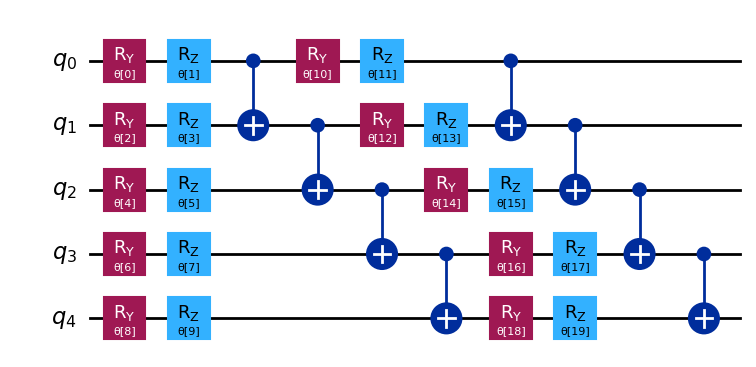

In [7]:
n_layers = 2

ansatz = build_hea_ansatz(n_qubits, n_layers, "HEA_test")
theta_params = ansatz.metadata["parameters"]

n_params = len(theta_params)

print("Number of parameters:", n_params)
ansatz.draw("mpl")

## Loss function

In [8]:
def mse_loss(params, ansatz, theta_params, p_target):
    p_model = get_prob_distribution(params, ansatz, theta_params)
    return np.sum((p_model - p_target) ** 2)

In [9]:
def make_mse_objective(ansatz, theta_params, p_target):
    
    def objective(params):
        return mse_loss(params, ansatz, theta_params, p_target)
    
    return objective

objective = make_mse_objective(ansatz, theta_params, p_target)

In [10]:
def make_compute_hessian(loss_value, step=None, method="central"):

    import numdifftools as nd

    def safe_loss(theta):
        try:
            theta = np.asarray(theta, dtype=np.float64)
            y = loss_value(theta)

            if np.isfinite(y):
                return float(y)

            return np.nan

        except Exception:
            return np.nan

    def compute_hessian(theta, indices=None):
        theta = np.asarray(theta, dtype=np.float64)

        if indices is None:
            indices = np.arange(theta.size)
        else:
            indices = np.asarray(indices, dtype=int)

        theta0 = theta.copy()
        z0 = theta0[indices].copy()

        def restricted_loss(z):
            theta_full = theta0.copy()
            theta_full[indices] = z
            return safe_loss(theta_full)

        if step is None:
            H = nd.Hessian(
                restricted_loss,
                method=method
            )(z0)
        else:
            H = nd.Hessian(
                restricted_loss,
                step=step,
                method=method
            )(z0)

        H = np.asarray(H, dtype=np.float64)
        H = 0.5 * (H + H.T)

        return H

    return compute_hessian

compute_hessian = make_compute_hessian(
    objective,
    step=None,          # ou par exemple step=1e-4
    method="central"
)

# Exploratory Landscape Analysis

In [11]:
df = ela.ela_difficulty(
    sample_once=sample_once,
    loss_value=objective,
    max_pairs=5000,
    compute_hessian=compute_hessian,
    n_curvature_points=64,
    curvature_dims=20,
    n_jobs=-1,
)

Global sampling:  25%|██▌       | 1024/4096 [00:01<00:04, 650.79it/s]

[ELA] N=1024, y_scale=1.721e-01, relative_change=1.074e-02


Global sampling:  38%|███▊      | 1536/4096 [00:02<00:03, 755.83it/s]

[ELA] N=1536, y_scale=1.717e-01, relative_change=2.125e-03


Global sampling:  50%|█████     | 2048/4096 [00:02<00:02, 785.62it/s]

...

[ELA] N=3584, y_scale=1.745e-01, relative_change=7.602e-03


[ELA] N=4096, y_scale=1.743e-01, relative_change=1.520e-03
[ELA] Global sampling completed:
      final y_scale            = 1.742789e-01
      last relative change     = 1.520e-03

[ELA] y_scale appears stable at N_max=4096. The maximum relative change over the last 2 checks is below rel_tol=2.000e-02.


Hessian curvature test:  19%|█▉        | 12/64 [00:58<04:15,  4.91s/it]   /home/gabriel/Desktop/public/landscape_visualisation/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Computing topology features...


            Section                                      Metric         Value                                                                      Description
          Convexity                   Convex violation fraction  4.368000e-01                              Fraction of sampled segments that violate convexity
          Convexity                         Mean normalized gap -3.860705e-02                                                   Mean of normalized gap values.
          Convexity                                    Mean gap -6.728396e-03                                                               Mean of gap values
          Convexity                       Median normalized gap -3.002158e-02                                                 Median of normalized gap values.
          Convexity                                  Median gap -5.232129e-03                                                             Median of gap values
          Curvature           Hessian conditio